# Project Overview:

In [1]:
# Import data exploration Liberaries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Load Dataset:

bridge_data = pd.read_csv('../data/bridge_digital_twin_dataset.csv')

bridge_data.head()

,Timestamp,Strain_microstrain,Deflection_mm,Vibration_ms2,Tilt_deg,Displacement_mm,Crack_Propagation_mm,Corrosion_Level_percent,Cable_Member_Tension_kN,Bearing_Joint_Forces_kN,...,Soil_Saturation_percent,Landslide_Ground_Movement,Simulated_Slope_Displacement_mm,High_Winds_Storms,Simulated_Wind_Load_Pressure_kPa,Abnormal_Traffic_Load_Surges,Simulated_Localized_Stress_Index,Energy_Harvesting_Potential_W,Estimated_Repair_Cost_USD_incremental,Carbon_Footprint_tCO2e_incremental
0,2023-01-01 00:00:00,NaN,12.663104,1.275955,0.587340,22.576518,-0.000083,0.002910,404.394906,233.052345,...,9.888758,0.0,0.022592,0.0,0.211946,0.0,0.215354,0.081403,1.343588,0.001348
1,2023-01-01 00:01:00,599.936448,12.235297,0.716857,0.657122,21.202649,0.000092,0.004601,367.821051,237.545735,...,9.920331,0.0,0.014647,0.0,0.231188,0.0,0.218747,0.107097,1.397207,0.001299
2,2023-01-01 00:02:00,573.878472,12.447144,0.834753,0.615011,NaN,-0.000377,0.005115,402.393742,239.164832,...,NaN,0.0,0.000000,0.0,0.199192,0.0,0.213449,0.141938,1.318876,0.001378
3,2023-01-01 00:03:00,550.457302,12.554883,1.004917,0.617999,21.551945,-0.000646,0.005505,356.024238,237.645586,...,43.526026,0.0,0.000000,0.0,0.198359,0.0,0.208190,0.192431,1.351773,0.001379
4,2023-01-01 00:04:00,572.829960,12.598818,1.176253,0.633534,21.711292,0.000247,-0.003415,413.338280,232.310381,...,44.138185,0.0,0.000000,0.0,0.188110,0.0,0.261240,0.261609,NaN,0.001267


In [12]:
bridge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 54 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Timestamp                              43200 non-null  object 
 1   Strain_microstrain                     41379 non-null  float64
 2   Deflection_mm                          41467 non-null  float64
 3   Vibration_ms2                          41478 non-null  float64
 4   Tilt_deg                               41447 non-null  float64
 5   Displacement_mm                        41473 non-null  float64
 6   Crack_Propagation_mm                   41494 non-null  float64
 7   Corrosion_Level_percent                41531 non-null  float64
 8   Cable_Member_Tension_kN                41459 non-null  float64
 9   Bearing_Joint_Forces_kN                41515 non-null  float64
 10  Fatigue_Accumulation_au                41496 non-null  float64
 11  Mo

In [13]:
bridge_data.columns

Index(['Timestamp', 'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2',
       'Tilt_deg', 'Displacement_mm', 'Crack_Propagation_mm',
       'Corrosion_Level_percent', 'Cable_Member_Tension_kN',
       'Bearing_Joint_Forces_kN', 'Fatigue_Accumulation_au',
       'Modal_Frequency_Hz', 'Temperature_C', 'Humidity_percent',
       'Wind_Speed_ms', 'Wind_Direction_deg', 'Precipitation_mmh',
       'Water_Level_m', 'Seismic_Activity_ms2', 'Solar_Radiation_Wm2',
       'Air_Quality_Index_AQI', 'Soil_Settlement_mm', 'Vehicle_Load_tons',
       'Traffic_Volume_vph', 'Pedestrian_Load_pph', 'Impact_Events_g',
       'Dynamic_Load_Distribution_percent', 'Axle_Counts_pmin',
       'Structural_Health_Index_SHI', 'Anomaly_Detection_Score',
       'Energy_Dissipation_au', 'Acoustic_Emissions_levels',
       'Visual_Analysis_Defect_Score', 'Electrical_Resistance_ohms',
       'Bridge_Mood_Meter', 'Localized_Strain_Hotspot',
       'Vibration_Anomaly_Location', 'SHI_Predicted_24h_Ahead',
       'SHI

In [14]:
bridge_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Strain_microstrain,41379.0,851.950836,351.908310,363.529753,618.866446,7.344767e+02,1072.661680,4074.893156
Deflection_mm,41467.0,15.145403,3.824032,6.889697,12.447132,1.498616e+01,17.090508,30.389080
Vibration_ms2,41478.0,1.339495,0.979641,0.637735,1.000030,1.198123e+00,1.532924,15.086480
Tilt_deg,41447.0,0.756122,0.142167,0.476074,0.667321,7.242946e-01,0.832503,1.522738
Displacement_mm,41473.0,22.703596,1.627841,18.964441,21.387484,2.236144e+01,23.985103,27.630262
Crack_Propagation_mm,41494.0,0.015036,0.009338,-0.001531,0.007511,1.502423e-02,0.022526,0.519706
Corrosion_Level_percent,41531.0,0.149950,0.086731,-0.010256,0.074979,1.501009e-01,0.224839,0.312679
Cable_Member_Tension_kN,41459.0,476.054924,91.773467,334.045442,396.924817,4.478997e+02,556.362810,844.862138
Bearing_Joint_Forces_kN,41515.0,276.967988,45.590840,205.758025,237.447819,2.600760e+02,318.127839,423.909686
Fatigue_Accumulation_au,41496.0,0.300012,0.173392,-0.022617,0.149817,2.998104e-01,0.450031,0.623392


# 1.0 Data Cleaning:

In [31]:
# I dentify missing data

bridge_data.isnull().sum().sort_values(ascending= False) / len(bridge_data) * 100

Vibration_Anomaly_Location               79.062500
Strain_microstrain                        4.215278
Humidity_percent                          4.127315
Estimated_Repair_Cost_USD_incremental     4.099537
Wind_Direction_deg                        4.092593
Landslide_Ground_Movement                 4.085648
Abnormal_Traffic_Load_Surges              4.081019
High_Winds_Storms                         4.069444
Vehicle_Load_tons                         4.064815
Localized_Strain_Hotspot                  4.060185
Tilt_deg                                  4.057870
Soil_Saturation_percent                   4.043981
Electrical_Resistance_ohms                4.041667
Probability_of_Failure_PoF                4.037037
Traffic_Volume_vph                        4.037037
Temperature_C                             4.034722
Flood_Event_Flag                          4.034722
Cable_Member_Tension_kN                   4.030093
Air_Quality_Index_AQI                     4.025463
SHI_Predicted_30d_Ahead        

In [11]:
class_columns = [column for column in bridge_data.columns if len(bridge_data[column].unique()) <= 5]

class_columns

['Bridge_Mood_Meter',
 'Localized_Strain_Hotspot',
 'Vibration_Anomaly_Location',
 'Maintenance_Alert',
 'Flood_Event_Flag',
 'Landslide_Ground_Movement',
 'High_Winds_Storms',
 'Abnormal_Traffic_Load_Surges']

In [26]:
def get_class_distribution(df, col=None):
    
    value_counts = df[col].value_counts() if col else df.value_counts()
    
    # Plot
    plt.figure(figsize=(8, 6))
    plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )
    plt.title(f'Class Distribution - {col}' if col else 'Class Distribution')
    plt.xlabel('Class Label')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Add counts on bars
    for patch in plot.patches:
        plt.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.1,
                int(patch.get_height()), ha='center', va='bottom')
    
    plt.show()
    
    # Print counts
    print("Class Distribution:")
    total = len(df[col]) if col else len(df)
    for label, count in value_counts.items():
        print(f"  {label}: {count} ({count/total*100:.1f}%)")

/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


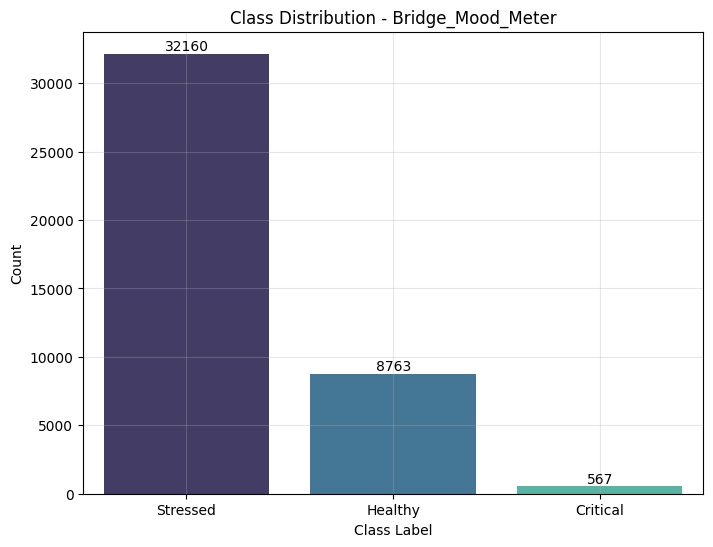

Class Distribution:
  Stressed: 32160 (74.4%)
  Healthy: 8763 (20.3%)
  Critical: 567 (1.3%)


/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


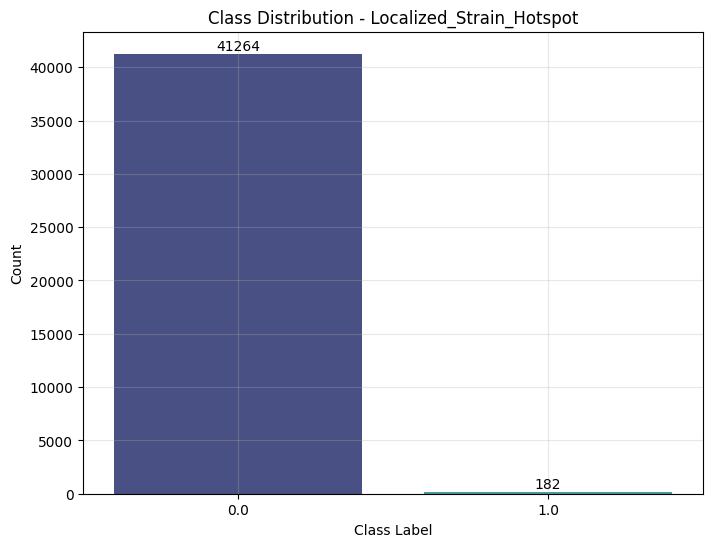

Class Distribution:
  0.0: 41264 (95.5%)
  1.0: 182 (0.4%)


/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


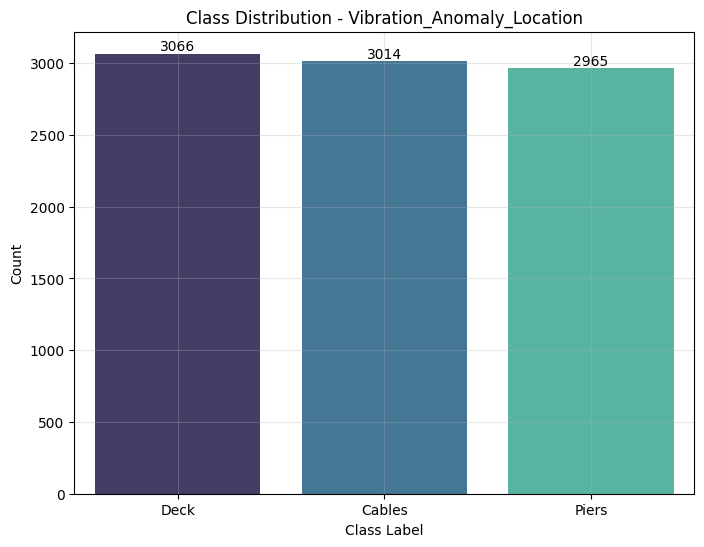

Class Distribution:
  Deck: 3066 (7.1%)
  Cables: 3014 (7.0%)
  Piers: 2965 (6.9%)


/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


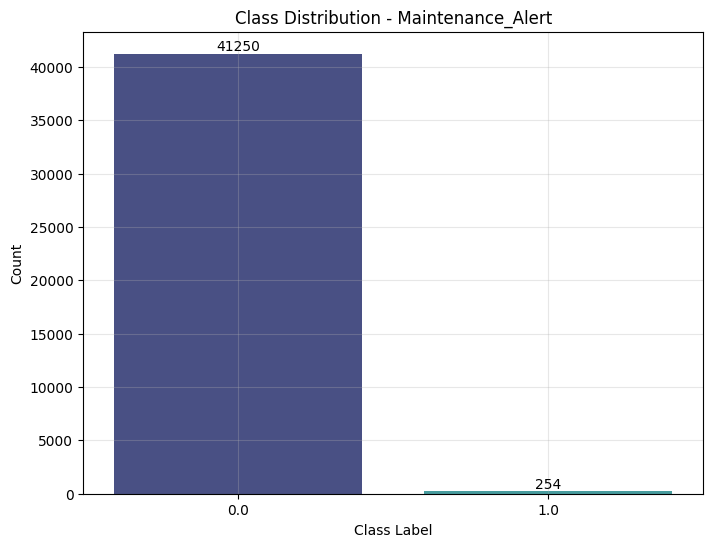

Class Distribution:
  0.0: 41250 (95.5%)
  1.0: 254 (0.6%)


/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


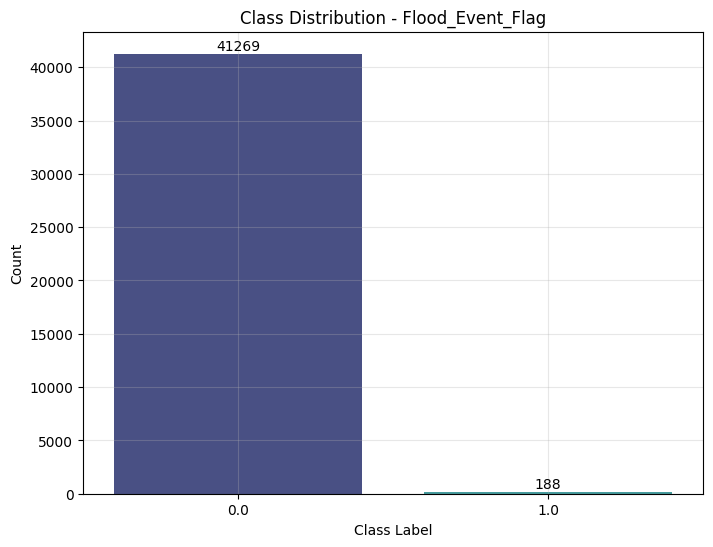

/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


Class Distribution:
  0.0: 41269 (95.5%)
  1.0: 188 (0.4%)


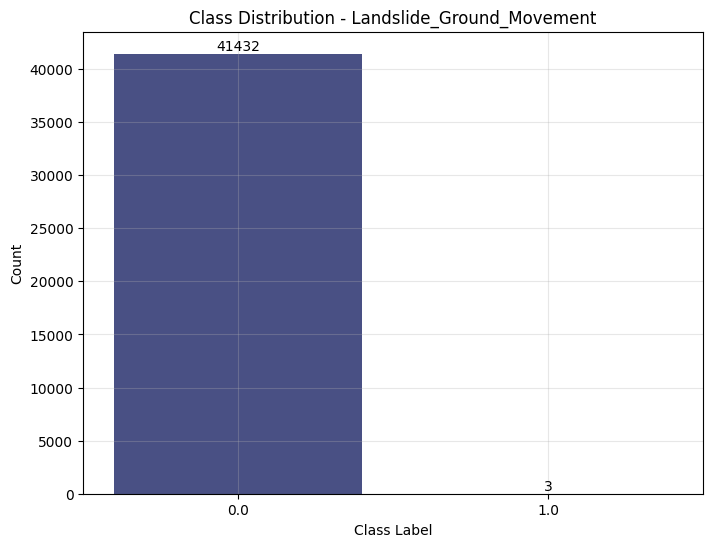

Class Distribution:
  0.0: 41432 (95.9%)
  1.0: 3 (0.0%)


/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


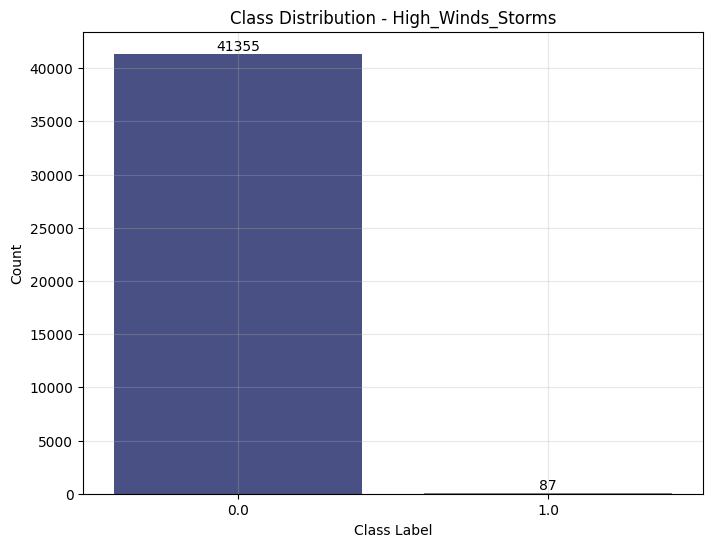

Class Distribution:
  0.0: 41355 (95.7%)
  1.0: 87 (0.2%)


/var/folders/3y/ydh4xsqs4pdd2wlc18yzhbsh0000gn/T/ipykernel_4947/793667259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=value_counts.index, y=value_counts.values , palette=  'mako' )


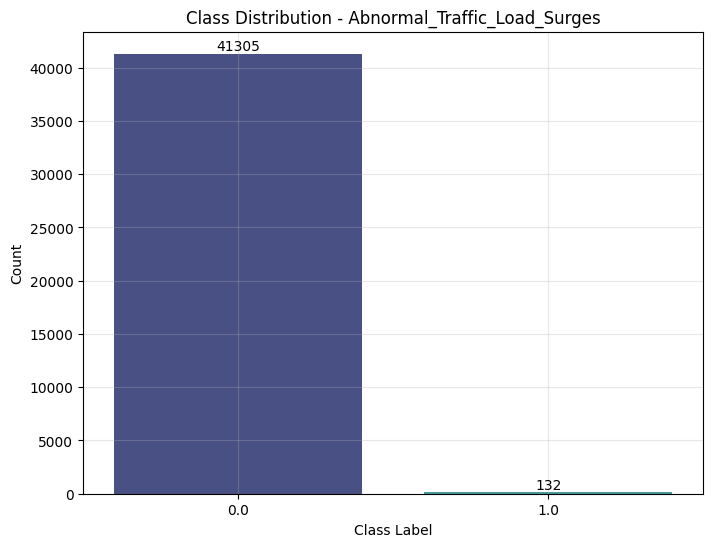

Class Distribution:
  0.0: 41305 (95.6%)
  1.0: 132 (0.3%)


In [27]:
# show classification label values distribution
for column in class_columns:
    get_class_distribution(bridge_data,column)
